### Import libraries and modules

In [9]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd
from src.data.training_matrix import build_training_matrix
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb

### Load X and y

In [ ]:
X, y = build_training_matrix()
print(f"The shape of X: {X.shape}, shape of y: {y.shape}, and X columns' name are: {X.columns.tolist()}")

The First 10 rows of the series `physics_pred` is: 
time
2022-01-01 00:00:00+00:00    0.0
2022-01-01 01:00:00+00:00    0.0
2022-01-01 02:00:00+00:00    0.0
2022-01-01 03:00:00+00:00    0.0
2022-01-01 04:00:00+00:00    0.0
Name: physics_pred, dtype: float64
The shape of X: (26279, 6), shape of y: (26279,), and total no. of X columns are: ['hour', 'month', 'cloud_cover_lag_1h', 'radiation_lag_1h', 'cloud_cover_rolling_3h', 'physics_pred']


### Train/Test split
`shuffle=False`-- footnote: time-series data must NOT be shuffled. If shuffled, future data leaks into training and metrics look unrealistically good. Hence, always split time-series chronologically.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

### Train XGBoost

In [5]:
model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6)
model.fit(X_train, y_train)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

### Evaluate XGBoost metrices

In [8]:
y_pred_residual = model.predict(X_test)
y_pred_total    = X_test["physics_pred"] + y_pred_residual
y_actual        = y_test + X_test["physics_pred"]
mae = mean_absolute_error(y_actual, y_pred_total)
rmse = mean_squared_error(y_actual, y_pred_total) ** 0.5
r2 = r2_score(y_actual, y_pred_total)
print(f"XGBoost MAE:  {mae:.1f} MW  | (Physics baseline: 3856 MW)")
print(f"XGBoost RMSE: {rmse:.1f} MW")
print(f"XGBoost R²:   {r2:.4f} | (Physics baseline: 0.78)")


XGBoost MAE:  1551.9 MW  | (Physics baseline: 3856 MW)
XGBoost RMSE: 3094.8 MW
XGBoost R²:   0.9286 | (Physics baseline: 0.78)


### feature importance plot

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

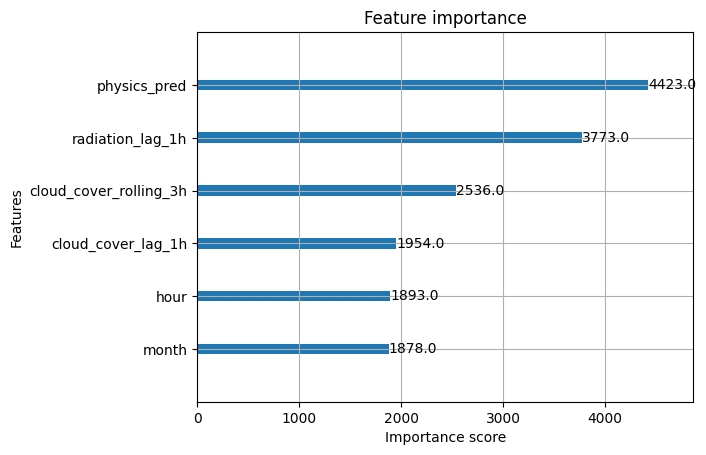

In [10]:
xgb.plot_importance(model, max_num_features=6)

# Summary

## Results: Physics + XGBoost vs Physics Alone

| Metric | Physics baseline | Physics + XGBoost | Improvement |
|---|---|---|---|
| MAE | 3,856 MW | 1,552 MW | −60% |
| RMSE | 5,179 MW | 3,095 MW | −40% |
| R² | 0.78 | 0.92 | +0.14 |

Top feature: `physics_pred`: confirms the hybrid architecture is correct.
XGBoost corrects cloud/time residuals that physics cannot model.
Next: calibrated uncertainty quantification (Phase 4).
